In [1]:
import h5ify
import pickle
import numpy as np
import matplotlib.pyplot as plt

from data import get_data

from util import plot_multiple

Compare my samples to the samples used by Stegmann

In [2]:
_, posteriors, injections = get_data(
    snr_thresh=10,
    far_thresh=1,
    prefer_xphm=False,
    prefer_xphm_gwtc3=True
)

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5


In [ ]:
import pandas as pd



[           a_1       a_2  cos_tilt_1  cos_tilt_2  mass_ratio       prior  \
 0     0.196903  0.134006   -0.185033   -0.356549    0.822441  396.670640   
 1     0.816376  0.519008   -0.721666    0.593088    0.962070  227.894704   
 2     0.532735  0.027996   -0.254188   -0.135848    0.869241  274.340022   
 3     0.115837  0.494337   -0.224535    0.226741    0.948335  292.719052   
 4     0.467142  0.132982   -0.446323   -0.055239    0.897050  285.657682   
 ...        ...       ...         ...         ...         ...         ...   
 6908  0.072748  0.290093    0.096240   -0.711806    0.926083  303.027042   
 6909  0.965755  0.571766   -0.620592    0.907632    0.839947  435.324919   
 6910  0.691533  0.566950   -0.296373    0.314724    0.988436  270.444635   
 6911  0.236562  0.771859    0.570706   -0.551067    0.686521  322.594549   
 6912  0.010086  0.256722    0.509300   -0.182269    0.715239  530.800003   
 
       redshift     mass_1  log_prior  
 0     0.108189  34.904242   5.983

In [3]:
with open(f'../../data/stegmann/gwtc4_posteriors.pkl', 'rb') as f:
    posteriors_stegmann = pickle.load(f)

In [4]:
from data import resample_and_reshape_posteriors

posteriors_stegmann = resample_and_reshape_posteriors(posteriors_stegmann)

In [17]:
posteriors['a_1'].shape

(153, 6913)

In [18]:

posteriors_stegmann['a_1'].shape

(153, 6913)

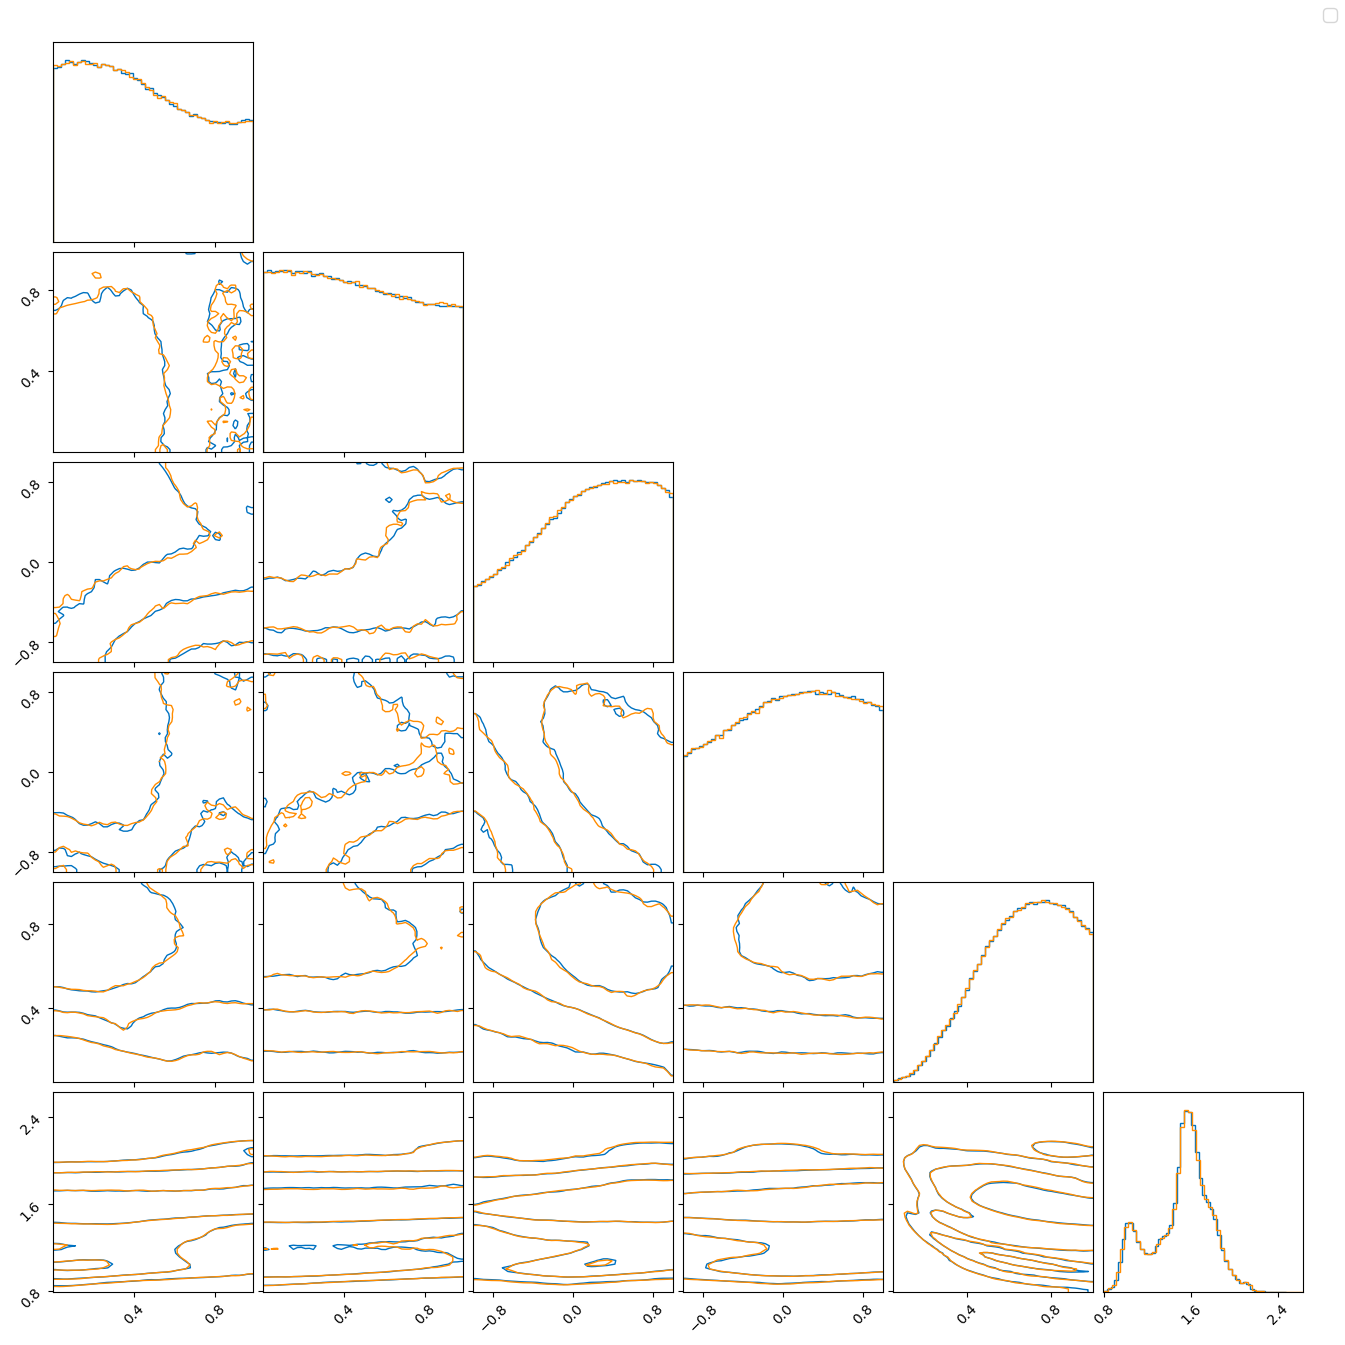

In [16]:
plot_multiple(
    [
        np.column_stack([
            posteriors['a_1'].flatten(),
            posteriors['a_2'].flatten(),
            posteriors['cos_tilt_1'].flatten(),
            posteriors['cos_tilt_2'].flatten(),
            posteriors['mass_ratio'].flatten(),
            np.log10(posteriors['mass_1'].flatten())
        ]),
        np.column_stack([
            posteriors_stegmann['a_1'].flatten(),
            posteriors_stegmann['a_2'].flatten(),
            posteriors_stegmann['cos_tilt_1'].flatten(),
            posteriors_stegmann['cos_tilt_2'].flatten(),
            posteriors_stegmann['mass_ratio'].flatten(),
            np.log10(posteriors_stegmann['mass_1'].flatten())
        ])    
    ],
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    levels=(0.5, 0.9, 0.99)
);

In [22]:
posteriors_stegmann['mass_1']

array([[34.90424173, 31.7821926 , 34.78075579, ..., 32.40410484,
        38.27086819, 37.81207449],
       [29.66274623, 22.90904947, 19.10687173, ..., 19.64571789,
        42.52284106, 21.560132  ],
       [12.95822666, 10.07653814, 11.98672838, ..., 10.92832095,
        13.10643817, 13.34223486],
       ...,
       [45.16656739, 43.42528522, 43.6169016 , ..., 44.98138636,
        47.60651875, 48.5650417 ],
       [41.89491481, 46.19636263, 62.70322596, ..., 47.17869639,
        51.61418538, 60.49565568],
       [37.94016875, 37.91253766, 24.02464295, ..., 23.35116886,
        31.40675231, 33.72879162]], shape=(153, 6913))

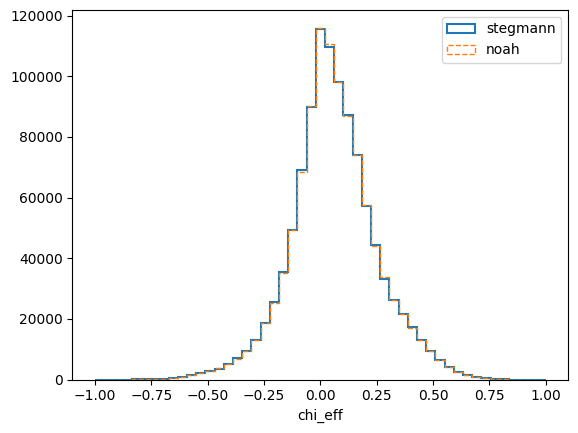

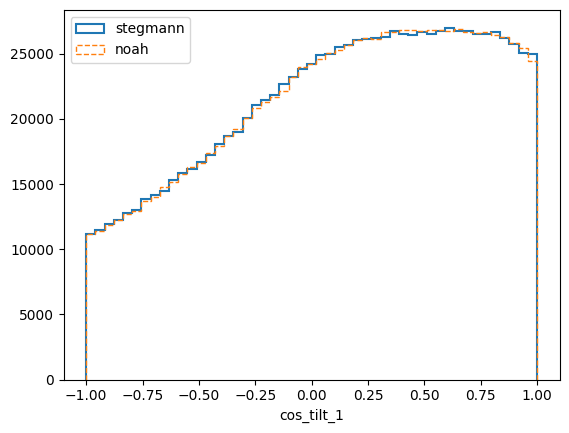

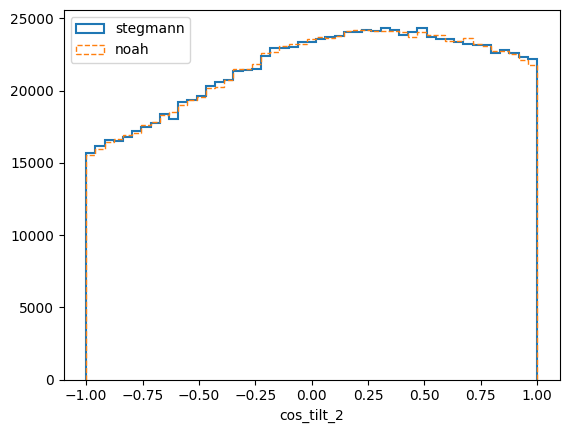

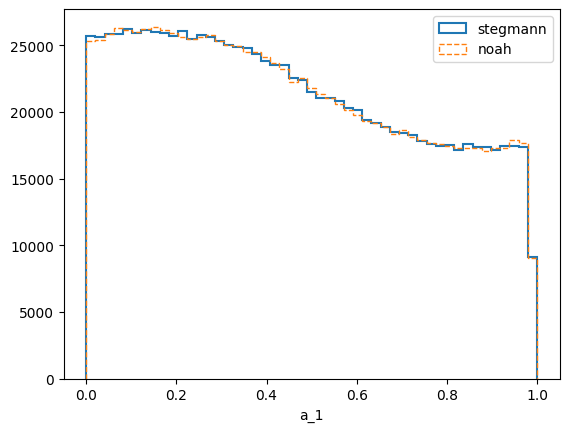

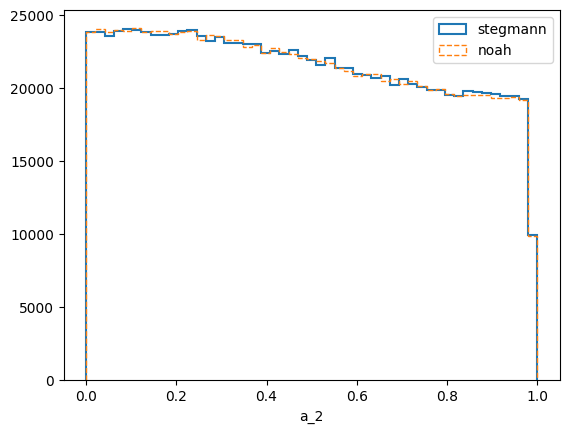

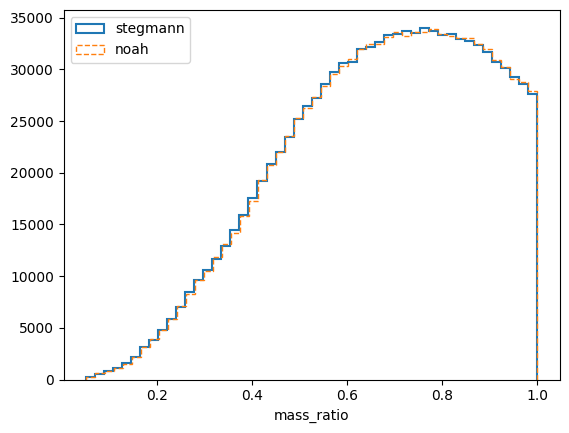

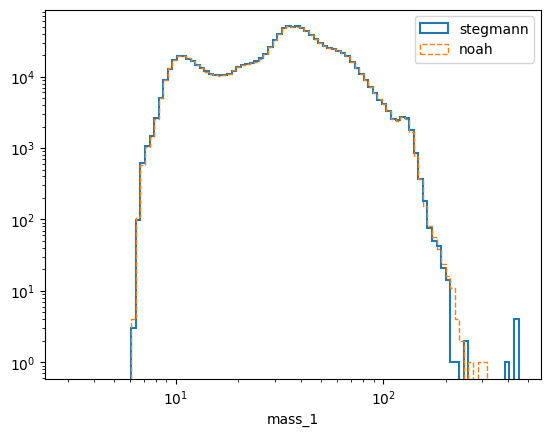

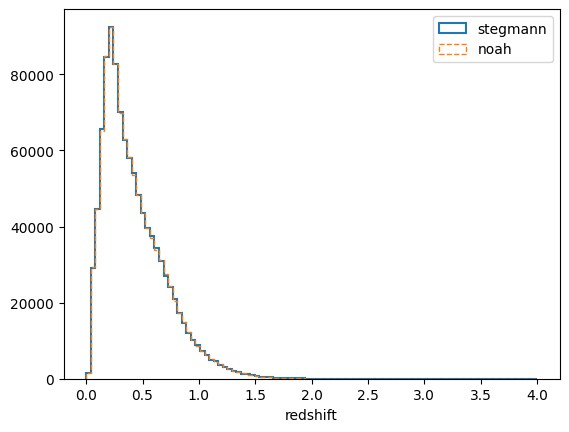

In [39]:
import numpy as np
from util import calc_chieff

posteriors_stegmann['chi_eff'] = calc_chieff(
    posteriors_stegmann['mass_ratio'],
    posteriors_stegmann['a_1'],
    posteriors_stegmann['a_2'],
    posteriors_stegmann['cos_tilt_1'],
    posteriors_stegmann['cos_tilt_2']
)

posteriors['chi_eff'] = calc_chieff(
    posteriors['mass_ratio'],
    posteriors['a_1'],
    posteriors['a_2'],
    posteriors['cos_tilt_1'],
    posteriors['cos_tilt_2']
)


bins = np.linspace(-1, 1, 50)

for key in['chi_eff', 'cos_tilt_1', 'cos_tilt_2', 'a_1', 'a_2', 'mass_ratio', 'mass_1', 'redshift']:
    if key in ['cos_tilt_1', 'cos_tilt_2', 'chi_eff']:
        bins = np.linspace(-1, 1, 50)
    elif key in ['a_1', 'a_2']:
        bins = np.linspace(0, 1, 50)
    elif key == 'mass_1':
        bins = np.logspace(np.log10(3), np.log10(450), 100) #np.linspace(0, 450, 100)
    elif key == 'redshift':
        bins = np.linspace(0, 4, 100)
    else:
        bins = 50

    fig, ax = plt.subplots()
    ax.hist(
        posteriors_stegmann[key].flatten(),
        histtype='step',
        bins=bins,
        label='stegmann',
        lw=1.5
    );

    ax.hist(
        posteriors[key].flatten(),
        histtype='step',
        bins=bins,
        label='noah',
        lw=1,
        linestyle='--'
    );
    ax.set_xlabel(key)

    if key == 'mass_1':
        ax.loglog()

    ax.legend();


In [30]:
with open(f'../../data/stegmann/gwtc4_injections_dict.pkl', 'rb') as f:
    injections_stegmann = pickle.load(f)

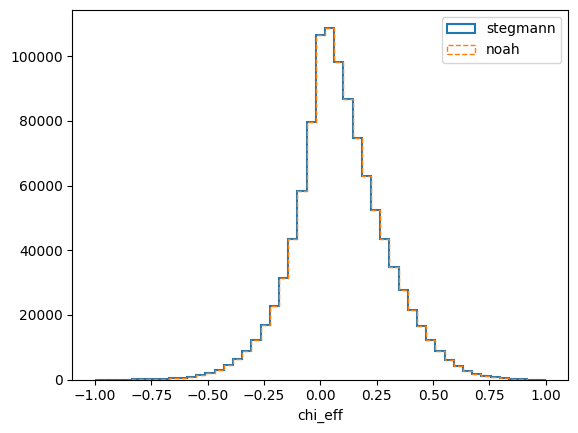

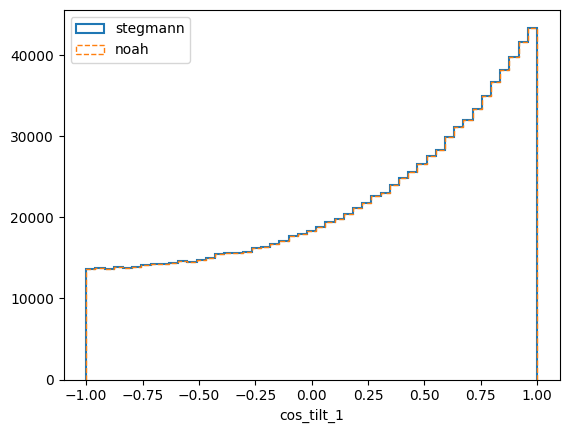

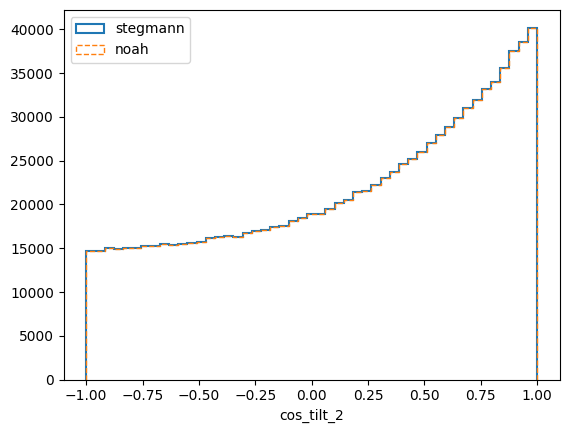

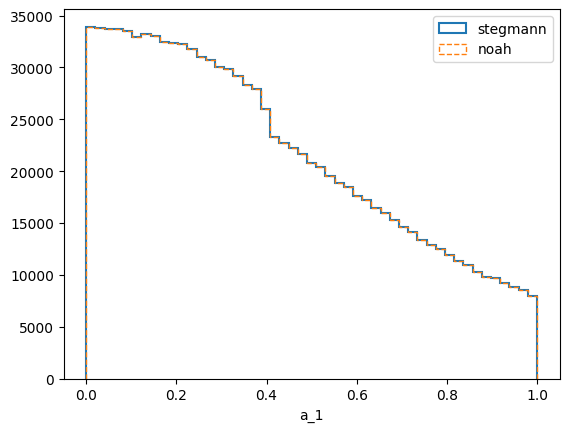

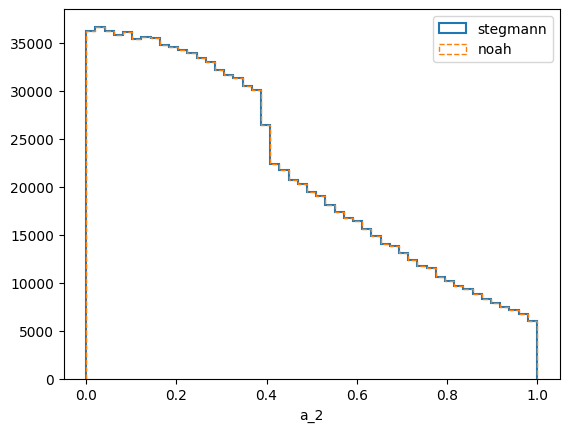

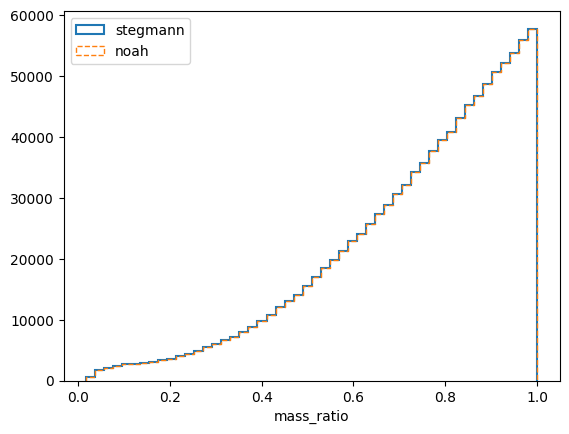

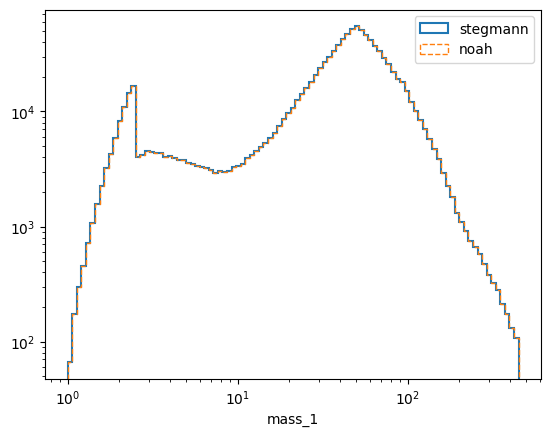

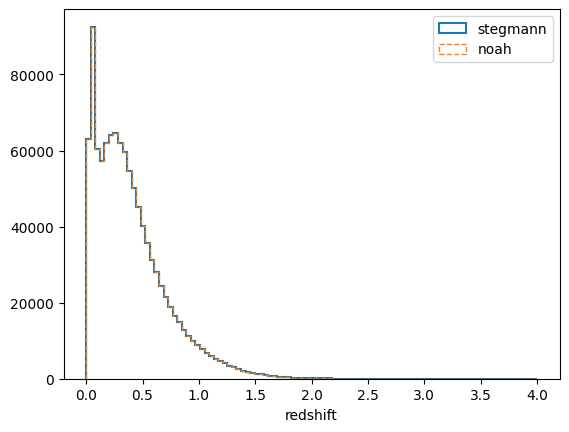

In [37]:
import numpy as np
from util import calc_chieff

injections_stegmann['chi_eff'] = calc_chieff(
    injections_stegmann['mass_ratio'],
    injections_stegmann['a_1'],
    injections_stegmann['a_2'],
    injections_stegmann['cos_tilt_1'],
    injections_stegmann['cos_tilt_2']
)

if 'chi_eff' not in injections:
    injections['chi_eff'] = calc_chieff(
        injections['mass_ratio'],
        injections['a_1'],
        injections['a_2'],
        injections['cos_tilt_1'],
        injections['cos_tilt_2']
    )


bins = np.linspace(-1, 1, 50)

for key in['chi_eff', 'cos_tilt_1', 'cos_tilt_2', 'a_1', 'a_2', 'mass_ratio', 'mass_1', 'redshift']:
    if key in ['cos_tilt_1', 'cos_tilt_2', 'chi_eff']:
        bins = np.linspace(-1, 1, 50)
    elif key in ['a_1', 'a_2']:
        bins = np.linspace(0, 1, 50)
    elif key == 'mass_1':
        bins = np.logspace(np.log10(1), np.log10(450), 100) #np.linspace(0, 450, 100)
    elif key == 'redshift':
        bins = np.linspace(0, 4, 100)
    else:
        bins = 50

    fig, ax = plt.subplots()
    ax.hist(
        injections_stegmann[key].flatten(),
        histtype='step',
        bins=bins,
        label='stegmann',
        lw=1.5
    );

    ax.hist(
        injections[key].flatten(),
        histtype='step',
        bins=bins,
        label='noah',
        lw=1,
        linestyle='--'
    );
    ax.set_xlabel(key)

    if key == 'mass_1':
        ax.loglog()

    ax.legend();


In [32]:
len(injections['chi_eff'])

1065922

In [34]:
injections_stegmann

{'mass_1': array([45.15422679, 20.46347243, 31.49269517, ..., 22.27432032,
        65.88646499,  2.25242744], shape=(1065922,)),
 'mass_ratio': array([0.44799082, 0.81033314, 0.74996786, ..., 0.73068224, 0.66393557,
        0.85476055], shape=(1065922,)),
 'a_1': array([0.16243093, 0.137373  , 0.02898515, ..., 0.99583277, 0.55638647,
        0.49881459], shape=(1065922,)),
 'a_2': array([0.3627992 , 0.28184632, 0.2437523 , ..., 0.95607815, 0.32076786,
        0.27731706], shape=(1065922,)),
 'cos_tilt_1': array([ 0.07403731,  0.72230954, -0.38512757, ...,  0.93889264,
         0.67981822, -0.2130991 ], shape=(1065922,)),
 'cos_tilt_2': array([ 0.71306297, -0.08572489,  0.94640479, ...,  0.88695208,
        -0.75479131, -0.3162247 ], shape=(1065922,)),
 'redshift': array([0.1502511 , 0.10812333, 0.183693  , ..., 0.38669392, 0.73260368,
        0.03056327], shape=(1065922,)),
 'prior': array([9.44182132e-05, 2.13199834e-04, 4.10222859e-04, ...,
        1.33253181e-05, 2.76813965e-05, 1.1

In [33]:
len(injections_stegmann['chi_eff'])

153